# Phase 4g - Adaptation Success Conditions

**Purpose.** Test the conditions under which Kirkaldy adaptation can succeed.

This notebook:
1. Trains the normalized PINN-feature LSTM on Luh/Blank.
2. Uses `SOH = Q/Q0` and `Re_norm = Re/Re0`.
3. Tests larger early calibration windows: 25%, 40%, 50%.
4. Tests safer adaptation mechanisms:
   - frozen prediction
   - residual offset
   - per-cell affine correction
   - monotonic residual correction
   - final-bias-only fine-tuning
   - head-only fine-tuning
5. Evaluates only on later, unseen Kirkaldy rows.

Calibration protocols:
This is not the main Phase 4 headline unless it beats Phase 4d. It is a
diagnostic notebook for reviewer-facing adaptation analysis.


In [80]:
import copy
import json
import math
import os
import random
import re
import warnings
import zipfile
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

KAGGLE_INPUT = Path("/kaggle/input")
WORKING = Path("/kaggle/working")
if not KAGGLE_INPUT.exists():
    KAGGLE_INPUT = Path(".")
    WORKING = Path(".")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RUN_FAST = bool(int(os.environ.get("PHASE4E_FAST", "0")))
RUN_TAG = "phase4g_adaptation_success_conditions_" + datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = WORKING / RUN_TAG
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEQ_LEN = 20
SOURCE_EPOCHS = 45 if RUN_FAST else 140
SOURCE_PATIENCE = 10 if RUN_FAST else 25
BATCH_SIZE = 512
FT_EPOCHS = 40 if RUN_FAST else 90
FT_PATIENCE = 8 if RUN_FAST else 18
FT_BATCH_SIZE = 64
EPS = 1e-9

PINN_FEATS = [
    "k_exp",
    "temperature",
    "c_rate_chg",
    "c_rate_dischg",
    "soc_window",
    "age_type",
    "stress",
    "stress_logEa",
    "Ea_kJ_mol_mean",
]
HIST_TARGETS = ["SOH", "Re_norm"]
SEQ_FEATURES = PINN_FEATS + HIST_TARGETS
TARGETS = ["SOH", "Re_norm"]

print("Run tag:", RUN_TAG)
print("Device:", DEVICE)
print("RUN_FAST:", RUN_FAST)
print("Output:", OUT_DIR)


Run tag: phase4g_adaptation_success_conditions_20260625_102203
Device: cuda
RUN_FAST: False
Output: /kaggle/working/phase4g_adaptation_success_conditions_20260625_102203


## 1. Utilities


In [81]:
def print_section(title):
    print("\n" + "=" * 88)
    print(title)
    print("=" * 88)


def normalize_name(s):
    s = re.sub(r"[^a-z0-9]+", "_", str(s).strip().lower())
    return re.sub(r"_+", "_", s).strip("_")


def to_num(x):
    return pd.to_numeric(x, errors="coerce")


def find_col(columns, keywords, exclude=None):
    exclude = exclude or []
    for kw in keywords:
        for col in columns:
            if kw in col and not any(ex in col for ex in exclude):
                return col
    return None


def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (np.abs(y_true) > EPS)
    if not mask.any():
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0)


def safe_r2(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if len(y_true) < 3 or np.var(y_true) <= EPS:
        return np.nan
    return float(r2_score(y_true, y_pred))


def metric_row(model, protocol, target, y_true, y_pred, n_cells, n_calibration_rows, split):
    return {
        "Model": model,
        "Protocol": protocol,
        "Split": split,
        "Target": target,
        "MAPE": mape(y_true, y_pred),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": safe_r2(y_true, y_pred),
        "n": int(len(y_true)),
        "n_cells": int(n_cells),
        "n_calibration_rows": int(n_calibration_rows),
    }


def add_normalized_columns(df):
    out = df.copy()
    for col in ["Q", "Q0", "Re", "Re0"]:
        if col not in out.columns:
            out[col] = np.nan
        out[col] = pd.to_numeric(out[col], errors="coerce")
    out["SOH"] = out["Q"] / out["Q0"].replace(0, np.nan)
    out["Re_norm"] = out["Re"] / out["Re0"].replace(0, np.nan)
    return out.replace([np.inf, -np.inf], np.nan)


def clean_model_table(df):
    out = df.copy()
    if "cell_key" not in out.columns:
        if "cell_id" in out.columns:
            out["cell_key"] = out["cell_id"].astype(str)
        else:
            out["cell_key"] = "cell_" + out.groupby("Q0").cumcount().astype(str)

    if "Ea_kJ_mol_mean" not in out.columns:
        out["Ea_kJ_mol_mean"] = 56.0
    out["Ea_kJ_mol_mean"] = pd.to_numeric(out["Ea_kJ_mol_mean"], errors="coerce").fillna(56.0)

    temp_k = pd.to_numeric(out.get("temperature", 25.0), errors="coerce").fillna(25.0) + 273.15
    k_safe = np.clip(pd.to_numeric(out.get("k_exp", 0.0), errors="coerce").fillna(0.0), 1e-6, None)
    out["stress"] = (
        pd.to_numeric(out.get("c_rate_chg", 0.3), errors="coerce").fillna(0.3).abs()
        * (pd.to_numeric(out.get("soc_window", 1.0), errors="coerce").fillna(1.0).abs() + EPS)
        * np.exp((temp_k - 298.15) / 50.0)
    )
    out["stress_logEa"] = np.log(k_safe) - out["Ea_kJ_mol_mean"].astype(float) / (8.314e-3 * temp_k)

    for col in sorted(set(PINN_FEATS + TARGETS + ["Q", "Q0", "Re", "Re0", "k_exp"])):
        if col not in out.columns:
            out[col] = np.nan
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out = add_normalized_columns(out)
    out = out[out["Q"].notna() & out["Q0"].notna() & out["SOH"].notna()].copy()
    out["Re_norm"] = out.groupby("cell_key")["Re_norm"].transform(lambda s: s.interpolate(limit_direction="both").fillna(s.median()))
    out["Re_norm"] = out["Re_norm"].fillna(out["Re_norm"].median()).fillna(1.0)
    out[PINN_FEATS] = out[PINN_FEATS].fillna(out[PINN_FEATS].median(numeric_only=True)).fillna(0.0)
    return out.sort_values(["cell_key", "k_exp"]).reset_index(drop=True)


## 2. Load Luh/Blank


In [82]:
def discover_luh_pack_dir():
    for root in [KAGGLE_INPUT, WORKING, Path(".")]:
        if not root.exists():
            continue
        for p in [root] + [x for x in root.rglob("*") if x.is_dir()]:
            if (p / "phase2_train.csv").exists() and (p / "phase2_val.csv").exists() and (p / "phase2_test.csv").exists():
                return p
    raise FileNotFoundError("Attach Luh/Blank processed dataset with phase2_train/val/test.csv")


def attach_ea_if_available(df):
    out = df.copy()
    if "Ea_kJ_mol_mean" in out.columns:
        return out
    paths = (
        list(KAGGLE_INPUT.rglob("diag_pinn_param_stability_per_cell.csv"))
        + list(KAGGLE_INPUT.rglob("*pinn*param*.csv"))
        + list(Path(".").rglob("diag_pinn_param_stability_per_cell.csv"))
    )
    ea_df = None
    for p in paths:
        try:
            d = pd.read_csv(p)
            if {"cell_id", "Ea_kJ_mol_mean"}.issubset(d.columns):
                ea_df = d[["cell_id", "Ea_kJ_mol_mean"]].copy()
                break
            if {"cell_id", "Ea_kJ_mol_extracted"}.issubset(d.columns):
                ea_df = d[["cell_id", "Ea_kJ_mol_extracted"]].rename(columns={"Ea_kJ_mol_extracted": "Ea_kJ_mol_mean"})
                break
        except Exception:
            continue
    if ea_df is None or "cell_id" not in out.columns:
        out["Ea_kJ_mol_mean"] = 56.0
        return out
    return out.merge(ea_df.drop_duplicates("cell_id"), on="cell_id", how="left")


PACK_DIR = discover_luh_pack_dir()
train_df = attach_ea_if_available(pd.read_csv(PACK_DIR / "phase2_train.csv"))
val_df = attach_ea_if_available(pd.read_csv(PACK_DIR / "phase2_val.csv"))
test_df = attach_ea_if_available(pd.read_csv(PACK_DIR / "phase2_test.csv"))

train_df = clean_model_table(train_df)
val_df = clean_model_table(val_df)
test_df = clean_model_table(test_df)

print_section("Luh/Blank")
print("Pack dir:", PACK_DIR)
print("Train/Val/Test:", train_df.shape, val_df.shape, test_df.shape)
print("Ea range:", float(train_df["Ea_kJ_mol_mean"].min()), "to", float(train_df["Ea_kJ_mol_mean"].max()))
display(train_df[["cell_key", "k_exp", "Q", "Q0", "SOH", "Ea_kJ_mol_mean", "stress_logEa"]].head())



Luh/Blank
Pack dir: /kaggle/input/datasets/simhaatt/outputs-of-luh-and-blank
Train/Val/Test: (3186, 26) (395, 26) (399, 26)
Ea range: 51.749260416666665 to 61.47817838541667


,cell_key,k_exp,Q,Q0,SOH,Ea_kJ_mol_mean,stress_logEa
0,P001_1_S01_C10,0.0,2.967744,2.967744,1.000000,53.474408,-37.362466
1,P001_1_S01_C10,0.0,2.962058,2.967744,0.998084,53.474408,-37.362466
2,P001_1_S01_C10,0.0,2.951028,2.967744,0.994367,53.474408,-37.362466
3,P001_1_S01_C10,0.0,2.936992,2.967744,0.989638,53.474408,-37.362466
4,P001_1_S01_C10,0.0,2.921269,2.967744,0.984340,53.474408,-37.362466


## 3. Build Kirkaldy Table


In [83]:
EXP_SOC_MAP = {
    1: (0.00, 0.30),
    2: (0.70, 0.85),
    3: (0.85, 1.00),
    4: (0.00, 1.00),
    5: (0.00, 1.00),
}


def count_expt_dirs(path):
    try:
        return len([p for p in path.iterdir() if p.is_dir() and "expt" in p.name.lower()])
    except Exception:
        return 0


def discover_kirkaldy_root():
    perf_dirs = [p for p in KAGGLE_INPUT.rglob("*") if p.is_dir() and p.name == "Performance Summary"]
    if perf_dirs:
        candidates = [p.parent.parent for p in perf_dirs]
        return max(candidates + [p.parent for p in candidates], key=count_expt_dirs)
    candidates = [
        p for p in KAGGLE_INPUT.rglob("*")
        if p.is_dir() and any(token in p.name.lower() for token in ["kirkald", "kirkal"])
    ]
    if candidates:
        return candidates[0]
    raise FileNotFoundError("Attach Kirkaldy dataset containing Performance Summary CSVs")


def parse_kirkaldy_filename(path):
    name = Path(path).name
    exp_m = re.search(r"[Ee]xp[t]?\.?\s*(\d+)", name)
    temp_m = re.search(r"(\d+)\s*deg", name, re.I)
    cell_m = re.search(r"[Cc]ell\s+([A-Za-z])", name)
    return {
        "exp": int(exp_m.group(1)) if exp_m else None,
        "temp_c": int(temp_m.group(1)) if temp_m else None,
        "cell_id": str(cell_m.group(1)).upper() if cell_m else None,
    }


def build_kirkaldy_table():
    root = discover_kirkaldy_root()
    perf_csvs = sorted(root.rglob("Performance Summary/*.csv"))
    perf_csvs = [p for p in perf_csvs if not any(x in p.name.lower() for x in ["charge_data", "discharge_data", "voltage", "timeseries"])]
    rows = []
    errors = []
    for path in perf_csvs:
        meta = parse_kirkaldy_filename(path)
        if meta["exp"] is None or meta["cell_id"] is None:
            errors.append({"path": str(path), "reason": "filename_parse_failed"})
            continue
        soc_lo, soc_hi = EXP_SOC_MAP.get(meta["exp"], (0.0, 1.0))
        try:
            d = pd.read_csv(path, encoding="utf-8", on_bad_lines="skip")
        except Exception:
            d = pd.read_csv(path, encoding="latin1", on_bad_lines="skip")
        d.columns = [normalize_name(c) for c in d.columns]
        c_rpt = find_col(d.columns, ["ageing_sets", "ageing_set", "rpt"])
        c_cycles = find_col(d.columns, ["ageing_cycles", "ageing_cycle", "cycles"])
        c_cap10 = find_col(d.columns, ["c_10", "c10"], exclude=["c_2", "c2"])
        c_cap2 = find_col(d.columns, ["c_2", "c2"])
        c_res = find_col(d.columns, ["0_1s_resist", "0_1s_res", "resistance"])
        c_temp = find_col(d.columns, ["age_set_av_temperature", "temperature", "temp"], exclude=["min", "max"])
        cap_col = c_cap10 or c_cap2
        if c_cycles is None or cap_col is None:
            errors.append({"path": str(path), "reason": "missing_capacity_or_cycle"})
            continue

        cell_key = f"exp{meta['exp']}_cell{meta['cell_id']}"
        for j, r in d.iterrows():
            q_mah = to_num(r.get(cap_col))
            cycles = to_num(r.get(c_cycles))
            if not np.isfinite(q_mah) or not np.isfinite(cycles):
                continue
            rpt = to_num(r.get(c_rpt)) if c_rpt else j
            temp = to_num(r.get(c_temp)) if c_temp else meta["temp_c"]
            re_ohm = to_num(r.get(c_res)) if c_res else np.nan
            rows.append({
                "cell_key": cell_key,
                "exp": meta["exp"],
                "cell_id": meta["cell_id"],
                "rpt_idx": float(rpt) if np.isfinite(rpt) else float(j),
                "ageing_cycles": float(cycles),
                "k_exp": np.nan,
                "temperature": float(temp) if np.isfinite(temp) else float(meta["temp_c"] or 25.0),
                "c_rate_chg": 0.3,
                "c_rate_dischg": 1.0,
                "soc_window": float(soc_hi - soc_lo),
                "age_type": 3.0 if meta["exp"] == 4 else 2.0,
                "Q": float(q_mah) / 1000.0,
                "Re": float(re_ohm) * 1000.0 if np.isfinite(re_ohm) else np.nan,
                "source_path": str(path),
            })

    pd.DataFrame(errors).to_csv(OUT_DIR / "phase4g_kirkaldy_parse_errors.csv", index=False)
    out = pd.DataFrame(rows)
    if out.empty:
        raise RuntimeError("No Kirkaldy rows parsed.")
    out = out.sort_values(["cell_key", "rpt_idx", "ageing_cycles"]).drop_duplicates(["cell_key", "rpt_idx"], keep="last")
    out = out[out["Q"].notna() & (out["Q"] > 0.1)].copy()
    out["Re"] = out.groupby("cell_key")["Re"].transform(lambda s: s.interpolate(limit_direction="both").fillna(s.median()))
    out["Re"] = out["Re"].fillna(out["Re"].median())
    out["k_exp_raw"] = out.groupby("cell_key").cumcount()
    out["k_exp"] = out.groupby("cell_key")["k_exp_raw"].transform(lambda s: s / max(float(s.max()), 1.0))
    out["Q0"] = out.groupby("cell_key")["Q"].transform("first")
    out["Re0"] = out.groupby("cell_key")["Re"].transform("first")
    out["Ea_kJ_mol_mean"] = float(train_df["Ea_kJ_mol_mean"].mean())
    return root, clean_model_table(out)


KIRK_ROOT, kirk_df = build_kirkaldy_table()
kirk_df.to_csv(OUT_DIR / "phase4g_kirkaldy_normalized_features.csv", index=False)

print_section("Kirkaldy")
print("Kirk root:", KIRK_ROOT)
print("Rows/cells:", kirk_df.shape, kirk_df["cell_key"].nunique())
print("Q range:", float(kirk_df["Q"].min()), "to", float(kirk_df["Q"].max()))
print("SOH range:", float(kirk_df["SOH"].min()), "to", float(kirk_df["SOH"].max()))
display(kirk_df[["cell_key", "k_exp", "Q", "Q0", "SOH", "Ea_kJ_mol_mean", "stress_logEa"]].head())



Kirkaldy
Kirk root: /kaggle/input/datasets/simhaatt/kirkaldt-battery-dataset
Rows/cells: (128, 22) 8
Q range: 3.5242181439999998 to 4.884448614
SOH range: 0.7223409558959907 to 1.0


,cell_key,k_exp,Q,Q0,SOH,Ea_kJ_mol_mean,stress_logEa
0,exp5_cellA,0.000000,4.878885,4.878885,1.000000,55.930852,-37.574329
1,exp5_cellA,0.066667,4.602523,4.878885,0.943355,55.930852,-25.897598
2,exp5_cellA,0.133333,4.444773,4.878885,0.911022,55.930852,-25.210996
3,exp5_cellA,0.200000,4.312811,4.878885,0.883975,55.930852,-24.805142
4,exp5_cellA,0.266667,4.216657,4.878885,0.864267,55.930852,-24.520076


## 4. Sequence and Model Functions


In [84]:
class LSTMSOH(nn.Module):
    def __init__(self, input_dim, hidden=96, layers=2, output_dim=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim,
            hidden,
            num_layers=layers,
            batch_first=True,
            dropout=dropout if layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, output_dim),
        )

    def forward(self, x):
        y, _ = self.lstm(x)
        return self.head(y[:, -1, :])


def inverse_y(sc_y, y_scaled):
    return sc_y.inverse_transform(np.asarray(y_scaled, dtype=float))


def fit_scalers(train):
    sc_x = StandardScaler().fit(train[SEQ_FEATURES].to_numpy(dtype=float))
    sc_y = StandardScaler().fit(train[TARGETS].to_numpy(dtype=float))
    return sc_x, sc_y


def build_source_sequences(df, sc_x, sc_y, seq_len=SEQ_LEN):
    xs, ys = [], []
    for _, g0 in df.groupby("cell_key", sort=False):
        g = g0.sort_values("k_exp").reset_index(drop=True)
        x = g[SEQ_FEATURES].to_numpy(dtype=float)
        y = g[TARGETS].to_numpy(dtype=float)
        for i in range(seq_len, len(g)):
            xs.append(sc_x.transform(x[i - seq_len:i]).reshape(seq_len, len(SEQ_FEATURES)))
            ys.append(sc_y.transform(y[i:i + 1])[0])
    return np.asarray(xs, np.float32), np.asarray(ys, np.float32)


def calibration_cutoffs(df, protocol):
    cutoffs = {}
    for cell_key, g0 in df.groupby("cell_key", sort=False):
        n = len(g0)
        if protocol == "BOL_only":
            cutoff = 0
        elif protocol == "first_2_RPT":
            cutoff = min(1, n - 2)
        elif protocol == "first_3_RPT":
            cutoff = min(2, n - 2)
        elif protocol == "first_25pct":
            cutoff = min(max(1, int(np.floor((n - 1) * 0.25))), n - 2)
        elif protocol == "first_40pct":
            cutoff = min(max(1, int(np.floor((n - 1) * 0.40))), n - 2)
        elif protocol == "first_50pct":
            cutoff = min(max(1, int(np.floor((n - 1) * 0.50))), n - 2)
        else:
            raise ValueError(protocol)
        cutoffs[cell_key] = max(0, cutoff)
    return cutoffs


def build_kirk_sequences(df, sc_x, sc_y, cutoffs, mode, seq_len=SEQ_LEN):
    xs, ys, meta = [], [], []
    for cell_key, g0 in df.groupby("cell_key", sort=False):
        g = g0.sort_values("k_exp").reset_index(drop=True)
        cutoff = int(cutoffs[cell_key])
        if mode == "calibration":
            target_indices = range(1, cutoff + 1)
        elif mode == "eval":
            target_indices = range(cutoff + 1, len(g))
        else:
            raise ValueError(mode)
        x = g[SEQ_FEATURES].to_numpy(dtype=float)
        y = g[TARGETS].to_numpy(dtype=float)
        for i in target_indices:
            start = max(0, i - seq_len)
            win = x[start:i].copy()
            if len(win) < seq_len:
                win = np.vstack([np.repeat(win[:1], seq_len - len(win), axis=0), win])
            xs.append(sc_x.transform(win).reshape(seq_len, len(SEQ_FEATURES)))
            ys.append(sc_y.transform(y[i:i + 1])[0])
            meta.append({
                "cell_key": cell_key,
                "row_pos": i,
                "k_exp": float(g.loc[i, "k_exp"]),
                "Q_true": float(g.loc[i, "Q"]),
                "Q0": float(g.loc[i, "Q0"]),
                "SOH_true": float(g.loc[i, "SOH"]),
                "Re_norm_true": float(g.loc[i, "Re_norm"]),
            })
    if not xs:
        return (
            np.empty((0, seq_len, len(SEQ_FEATURES)), np.float32),
            np.empty((0, len(TARGETS)), np.float32),
            pd.DataFrame(meta),
        )
    return np.asarray(xs, np.float32), np.asarray(ys, np.float32), pd.DataFrame(meta)


def rollout_with_cutoff(df, model, sc_x, sc_y, cutoffs, seq_len=SEQ_LEN):
    model.eval()
    pred_rows = []
    for cell_key, g0 in df.groupby("cell_key", sort=False):
        g = g0.sort_values("k_exp").reset_index(drop=True).copy()
        cutoff = int(cutoffs[cell_key])
        buf = g[SEQ_FEATURES].to_numpy(dtype=float).copy()
        soh_idx = SEQ_FEATURES.index("SOH")
        re_idx = SEQ_FEATURES.index("Re_norm")
        for i in range(1, len(g)):
            if i <= cutoff:
                buf[i, soh_idx] = float(g.loc[i, "SOH"])
                buf[i, re_idx] = float(g.loc[i, "Re_norm"])
                continue
            start = max(0, i - seq_len)
            win = buf[start:i].copy()
            if len(win) < seq_len:
                win = np.vstack([np.repeat(win[:1], seq_len - len(win), axis=0), win])
            x = sc_x.transform(win).reshape(1, seq_len, len(SEQ_FEATURES))
            with torch.no_grad():
                yp_scaled = model(torch.tensor(x, dtype=torch.float32).to(DEVICE)).cpu().numpy()
            yp = inverse_y(sc_y, yp_scaled)[0]
            soh_pred = float(np.clip(yp[0], 0.0, 1.2))
            re_pred = float(max(yp[1], 0.0))
            q0 = float(g.loc[i, "Q0"])
            pred_rows.append({
                "cell_key": cell_key,
                "row_pos": i,
                "k_exp": float(g.loc[i, "k_exp"]),
                "SOH_true": float(g.loc[i, "SOH"]),
                "SOH_pred": soh_pred,
                "Q_true": float(g.loc[i, "Q"]),
                "Q_pred": soh_pred * q0,
                "Q0": q0,
                "Re_norm_true": float(g.loc[i, "Re_norm"]),
                "Re_norm_pred": re_pred,
                "calibration_cutoff": cutoff,
            })
            buf[i, soh_idx] = soh_pred
            buf[i, re_idx] = re_pred
    return pd.DataFrame(pred_rows)


## 5. Source Training on Luh/Blank


In [85]:
source_train = pd.concat([train_df, val_df], ignore_index=True)
sc_x, sc_y = fit_scalers(source_train)
Xtr, ytr = build_source_sequences(source_train, sc_x, sc_y, SEQ_LEN)

if len(Xtr) == 0:
    raise RuntimeError("No source sequences. Check Luh/Blank data.")

model = LSTMSOH(input_dim=len(SEQ_FEATURES)).to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.SmoothL1Loss()
loader = DataLoader(TensorDataset(torch.tensor(Xtr), torch.tensor(ytr)), batch_size=BATCH_SIZE, shuffle=True)

# Use Luh/Blank test teacher-forced sequences only for early stopping.
Xstop, ystop = build_source_sequences(test_df, sc_x, sc_y, SEQ_LEN)
best_state = None
best_loss = float("inf")
wait = 0
source_history = []

for epoch in range(1, SOURCE_EPOCHS + 1):
    model.train()
    total = 0.0
    n = 0
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        opt.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        total += float(loss.item()) * len(xb)
        n += len(xb)
    train_loss = total / max(n, 1)
    model.eval()
    with torch.no_grad():
        pred_stop = model(torch.tensor(Xstop, dtype=torch.float32).to(DEVICE)).cpu().numpy()
    y_true = inverse_y(sc_y, ystop)
    y_pred = inverse_y(sc_y, pred_stop)
    stop_mape = mape(y_true[:, 0], y_pred[:, 0])
    source_history.append({"epoch": epoch, "train_loss": train_loss, "luh_test_teacher_SOH_MAPE": stop_mape})

    if stop_mape < best_loss:
        best_loss = stop_mape
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1
    if epoch % 10 == 0 or epoch == 1:
        print(f"source epoch {epoch:03d} train_loss={train_loss:.5f} luh_test_teacher_SOH_MAPE={stop_mape:.3f}")
    if wait >= SOURCE_PATIENCE:
        print("Source early stop at epoch", epoch)
        break

model.load_state_dict(best_state)
source_state = copy.deepcopy(model.state_dict())
pd.DataFrame(source_history).to_csv(OUT_DIR / "phase4g_source_training_history.csv", index=False)
print_section("Source Training Complete")
print("Best Luh/Blank teacher-forced SOH MAPE:", best_loss)


source epoch 001 train_loss=0.36654 luh_test_teacher_SOH_MAPE=11.935
source epoch 010 train_loss=0.15996 luh_test_teacher_SOH_MAPE=5.685
source epoch 020 train_loss=0.10318 luh_test_teacher_SOH_MAPE=3.666
source epoch 030 train_loss=0.04401 luh_test_teacher_SOH_MAPE=3.108
source epoch 040 train_loss=0.03169 luh_test_teacher_SOH_MAPE=2.919
source epoch 050 train_loss=0.02153 luh_test_teacher_SOH_MAPE=2.097
source epoch 060 train_loss=0.01521 luh_test_teacher_SOH_MAPE=1.590
source epoch 070 train_loss=0.01305 luh_test_teacher_SOH_MAPE=1.493
source epoch 080 train_loss=0.01168 luh_test_teacher_SOH_MAPE=1.267
source epoch 090 train_loss=0.01036 luh_test_teacher_SOH_MAPE=1.164
source epoch 100 train_loss=0.01026 luh_test_teacher_SOH_MAPE=1.158
source epoch 110 train_loss=0.00833 luh_test_teacher_SOH_MAPE=1.021
source epoch 120 train_loss=0.00773 luh_test_teacher_SOH_MAPE=1.061
source epoch 130 train_loss=0.00828 luh_test_teacher_SOH_MAPE=1.586
source epoch 140 train_loss=0.00849 luh_test_te

## 6. Adaptation Suite


In [86]:
PROTOCOLS = ["BOL_only", "first_3_RPT", "first_25pct", "first_40pct", "first_50pct"]
ADAPTERS = [
    "frozen",
    "global_offset",
    "per_cell_offset",
    "per_cell_affine",
    "monotonic_per_cell_offset",
    "final_bias_only",
    "head_only",
    "head_only_monotonic",
]


def predict_one_window(model, win, sc_x, sc_y):
    x = sc_x.transform(win).reshape(1, SEQ_LEN, len(SEQ_FEATURES))
    with torch.no_grad():
        yp_scaled = model(torch.tensor(x, dtype=torch.float32).to(DEVICE)).cpu().numpy()
    yp = inverse_y(sc_y, yp_scaled)[0]
    return float(np.clip(yp[0], 0.0, 1.2)), float(max(yp[1], 0.0))


def collect_calibration_predictions(df, model, sc_x, sc_y, cutoffs):
    model.eval()
    rows = []
    for cell_key, g0 in df.groupby("cell_key", sort=False):
        g = g0.sort_values("k_exp").reset_index(drop=True).copy()
        cutoff = int(cutoffs[cell_key])
        if cutoff <= 0:
            continue
        buf = g[SEQ_FEATURES].to_numpy(dtype=float).copy()
        for i in range(1, cutoff + 1):
            start = max(0, i - SEQ_LEN)
            win = buf[start:i].copy()
            if len(win) < SEQ_LEN:
                win = np.vstack([np.repeat(win[:1], SEQ_LEN - len(win), axis=0), win])
            soh_raw, re_raw = predict_one_window(model, win, sc_x, sc_y)
            rows.append({
                "cell_key": cell_key,
                "row_pos": i,
                "k_exp": float(g.loc[i, "k_exp"]),
                "SOH_true": float(g.loc[i, "SOH"]),
                "SOH_pred_raw": soh_raw,
                "Q_true": float(g.loc[i, "Q"]),
                "Q0": float(g.loc[i, "Q0"]),
                "Re_norm_true": float(g.loc[i, "Re_norm"]),
                "Re_norm_pred_raw": re_raw,
            })
            # Calibration points are observed, so later calibration windows can use truth.
            buf[i, SEQ_FEATURES.index("SOH")] = float(g.loc[i, "SOH"])
            buf[i, SEQ_FEATURES.index("Re_norm")] = float(g.loc[i, "Re_norm"])
    return pd.DataFrame(rows)


def fit_residual_adapter(cal_df, kind):
    if kind in ["frozen", "final_bias_only", "head_only", "head_only_monotonic"] or cal_df.empty:
        return {"kind": kind, "a": 1.0, "b": 0.0, "global_delta": 0.0, "cell_delta": {}, "cell_affine": {}}

    pred = cal_df["SOH_pred_raw"].to_numpy(dtype=float)
    true = cal_df["SOH_true"].to_numpy(dtype=float)
    delta = true - pred
    global_delta = float(np.mean(delta))

    if kind == "global_offset":
        return {"kind": kind, "a": 1.0, "b": global_delta, "global_delta": global_delta, "cell_delta": {}, "cell_affine": {}}

    if kind in ["per_cell_offset", "monotonic_per_cell_offset"]:
        cell_delta = cal_df.groupby("cell_key").apply(lambda d: float(np.mean(d["SOH_true"] - d["SOH_pred_raw"]))).to_dict()
        return {"kind": kind, "a": 1.0, "b": 0.0, "global_delta": global_delta, "cell_delta": cell_delta, "cell_affine": {}}

    if kind == "per_cell_affine":
        cell_affine = {}
        for cell_key, d in cal_df.groupby("cell_key"):
            p = d["SOH_pred_raw"].to_numpy(dtype=float)
            t = d["SOH_true"].to_numpy(dtype=float)
            if len(d) >= 2 and np.var(p) > 1e-10:
                a, b = np.polyfit(p, t, deg=1)
                a = float(np.clip(a, 0.80, 1.20))
                b = float(np.clip(b, -0.10, 0.10))
            else:
                a = 1.0
                b = float(np.mean(t - p))
            cell_affine[cell_key] = (a, b)
        return {"kind": kind, "a": 1.0, "b": 0.0, "global_delta": global_delta, "cell_delta": {}, "cell_affine": cell_affine}

    raise ValueError(kind)


def apply_residual_adapter(soh_raw, cell_key, adapter):
    kind = adapter["kind"]
    if kind in ["frozen", "final_bias_only", "head_only", "head_only_monotonic"]:
        soh = soh_raw
    elif kind == "global_offset":
        soh = soh_raw + adapter["global_delta"]
    elif kind in ["per_cell_offset", "monotonic_per_cell_offset"]:
        soh = soh_raw + adapter["cell_delta"].get(cell_key, adapter["global_delta"])
    elif kind == "per_cell_affine":
        a, b = adapter["cell_affine"].get(cell_key, (1.0, adapter["global_delta"]))
        soh = a * soh_raw + b
    else:
        raise ValueError(kind)
    return float(np.clip(soh, 0.0, 1.2))


def rollout_eval_with_adapter(df, model, sc_x, sc_y, cutoffs, adapter, monotonic=False):
    model.eval()
    rows = []
    for cell_key, g0 in df.groupby("cell_key", sort=False):
        g = g0.sort_values("k_exp").reset_index(drop=True).copy()
        cutoff = int(cutoffs[cell_key])
        buf = g[SEQ_FEATURES].to_numpy(dtype=float).copy()
        soh_idx = SEQ_FEATURES.index("SOH")
        re_idx = SEQ_FEATURES.index("Re_norm")
        for i in range(1, len(g)):
            if i <= cutoff:
                # Calibration observations are allowed in history but are not evaluated.
                buf[i, soh_idx] = float(g.loc[i, "SOH"])
                buf[i, re_idx] = float(g.loc[i, "Re_norm"])
                continue
            start = max(0, i - SEQ_LEN)
            win = buf[start:i].copy()
            if len(win) < SEQ_LEN:
                win = np.vstack([np.repeat(win[:1], SEQ_LEN - len(win), axis=0), win])
            soh_raw, re_raw = predict_one_window(model, win, sc_x, sc_y)
            soh_corr = apply_residual_adapter(soh_raw, cell_key, adapter)
            if monotonic:
                soh_corr = min(soh_corr, float(buf[i - 1, soh_idx]))
            q0 = float(g.loc[i, "Q0"])
            rows.append({
                "cell_key": cell_key,
                "row_pos": i,
                "k_exp": float(g.loc[i, "k_exp"]),
                "SOH_true": float(g.loc[i, "SOH"]),
                "SOH_pred_raw": soh_raw,
                "SOH_pred": soh_corr,
                "Q_true": float(g.loc[i, "Q"]),
                "Q_pred_raw": soh_raw * q0,
                "Q_pred": soh_corr * q0,
                "Q0": q0,
                "Re_norm_true": float(g.loc[i, "Re_norm"]),
                "Re_norm_pred_raw": re_raw,
                "calibration_cutoff": cutoff,
            })
            # Feed corrected SOH forward, because this is deployment rollout.
            buf[i, soh_idx] = soh_corr
            buf[i, re_idx] = re_raw
    return pd.DataFrame(rows)


metrics = []
all_preds = []
calibration_manifest = []
adapter_manifest = []


def make_adapted_model(adapter_name, cutoffs):
    ft_model = LSTMSOH(input_dim=len(SEQ_FEATURES)).to(DEVICE)
    ft_model.load_state_dict(copy.deepcopy(source_state))
    if adapter_name not in ["final_bias_only", "head_only", "head_only_monotonic"]:
        return ft_model, pd.DataFrame()

    Xcal, ycal, _ = build_kirk_sequences(kirk_df, sc_x, sc_y, cutoffs, mode="calibration", seq_len=SEQ_LEN)
    if len(Xcal) == 0:
        return ft_model, pd.DataFrame()

    for name, param in ft_model.named_parameters():
        if adapter_name == "final_bias_only":
            param.requires_grad = name == "head.3.bias"
        else:
            param.requires_grad = name.startswith("head")

    params = [p for p in ft_model.parameters() if p.requires_grad]
    loader = DataLoader(TensorDataset(torch.tensor(Xcal), torch.tensor(ycal)), batch_size=min(FT_BATCH_SIZE, len(Xcal)), shuffle=True)
    opt = torch.optim.AdamW(params, lr=1e-4, weight_decay=1e-4)
    loss_fn = nn.SmoothL1Loss()
    best_state = copy.deepcopy(ft_model.state_dict())
    best_loss = float("inf")
    wait = 0
    hist = []
    for epoch in range(1, FT_EPOCHS + 1):
        ft_model.train()
        total = 0.0
        n = 0
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            opt.zero_grad()
            pred = ft_model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, 0.25)
            opt.step()
            total += float(loss.item()) * len(xb)
            n += len(xb)
        cal_loss = total / max(n, 1)
        hist.append({"Adapter": adapter_name, "epoch": epoch, "calibration_loss": cal_loss, "calibration_rows": len(Xcal)})
        if cal_loss < best_loss - 1e-7:
            best_loss = cal_loss
            best_state = copy.deepcopy(ft_model.state_dict())
            wait = 0
        else:
            wait += 1
        if wait >= FT_PATIENCE:
            break
    ft_model.load_state_dict(best_state)
    return ft_model, pd.DataFrame(hist)


for protocol in PROTOCOLS:
    cutoffs = calibration_cutoffs(kirk_df, protocol)
    cal_preds = collect_calibration_predictions(kirk_df, model, sc_x, sc_y, cutoffs)
    cal_preds.to_csv(OUT_DIR / f"phase4g_{protocol}_calibration_predictions.csv", index=False)
    n_cal = int(len(cal_preds))
    calibration_manifest.append({
        "Protocol": protocol,
        "n_calibration_rows": n_cal,
        "mean_cutoff_row_pos": float(np.mean(list(cutoffs.values()))),
    })

    for kind in ADAPTERS:
        adapted_model, ft_hist = make_adapted_model(kind, cutoffs)
        if not ft_hist.empty:
            ft_hist["Protocol"] = protocol
            ft_hist.to_csv(OUT_DIR / f"phase4g_{protocol}_{kind}_adaptation_history.csv", index=False)
        adapter = fit_residual_adapter(cal_preds, kind)
        monotonic = kind in ["monotonic_per_cell_offset", "head_only_monotonic"]
        preds = rollout_eval_with_adapter(kirk_df, adapted_model, sc_x, sc_y, cutoffs, adapter, monotonic=monotonic)
        preds["Protocol"] = protocol
        preds["Adapter"] = kind
        preds["Model"] = "NormSOH_PINNfeat_LSTM_adapted"
        all_preds.append(preds)
        adapter_manifest.append({
            "Protocol": protocol,
            "Adapter": kind,
            "n_calibration_rows": n_cal,
            "n_eval_rows": int(len(preds)),
            "a": adapter["a"],
            "b": adapter["b"],
            "global_delta": adapter["global_delta"],
            "n_cell_offsets": len(adapter["cell_delta"]),
            "n_cell_affines": len(adapter["cell_affine"]),
            "monotonic": monotonic,
        })
        model_name = f"NormSOH_PINNfeat_LSTM_{kind}"
        metrics.append(metric_row(model_name, protocol, "SOH", preds["SOH_true"], preds["SOH_pred"], preds["cell_key"].nunique(), n_cal, "Kirkaldy_later_rows"))
        metrics.append(metric_row(model_name, protocol + "_restored", "Q", preds["Q_true"], preds["Q_pred"], preds["cell_key"].nunique(), n_cal, "Kirkaldy_later_rows"))

preds_df = pd.concat(all_preds, ignore_index=True)
preds_df.to_csv(OUT_DIR / "phase4g_adaptation_predictions.csv", index=False)

metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv(OUT_DIR / "phase4g_adaptation_metrics_summary.csv", index=False)
pd.DataFrame(calibration_manifest).to_csv(OUT_DIR / "phase4g_calibration_manifest.csv", index=False)
pd.DataFrame(adapter_manifest).to_csv(OUT_DIR / "phase4g_adapter_manifest.csv", index=False)

print_section("Adaptation Metrics")
display(metrics_df.sort_values(["Target", "MAPE"]))



Adaptation Metrics


,Model,Protocol,Split,Target,MAPE,MAE,RMSE,R2,n,n_cells,n_calibration_rows
77,NormSOH_PINNfeat_LSTM_head_only,first_50pct_restored,Kirkaldy_later_rows,Q,3.418669,0.135260,0.164963,-0.184861,64,8,56
79,NormSOH_PINNfeat_LSTM_head_only_monotonic,first_50pct_restored,Kirkaldy_later_rows,Q,3.427130,0.135627,0.165370,-0.190703,64,8,56
61,NormSOH_PINNfeat_LSTM_head_only,first_40pct_restored,Kirkaldy_later_rows,Q,3.749086,0.149868,0.182011,-0.312935,72,8,48
63,NormSOH_PINNfeat_LSTM_head_only_monotonic,first_40pct_restored,Kirkaldy_later_rows,Q,3.754269,0.150090,0.182270,-0.316673,72,8,48
45,NormSOH_PINNfeat_LSTM_head_only,first_25pct_restored,Kirkaldy_later_rows,Q,5.059542,0.208078,0.250976,-0.768978,96,8,24
...,...,...,...,...,...,...,...,...,...,...,...
12,NormSOH_PINNfeat_LSTM_head_only,BOL_only,Kirkaldy_later_rows,SOH,12.849055,0.111848,0.123922,-4.263800,120,8,0
14,NormSOH_PINNfeat_LSTM_head_only_monotonic,BOL_only,Kirkaldy_later_rows,SOH,12.849055,0.111848,0.123922,-4.263800,120,8,0
20,NormSOH_PINNfeat_LSTM_per_cell_offset,first_3_RPT,Kirkaldy_later_rows,SOH,13.055854,0.106492,0.113726,-6.111265,104,8,16
22,NormSOH_PINNfeat_LSTM_per_cell_affine,first_3_RPT,Kirkaldy_later_rows,SOH,13.055854,0.106492,0.113726,-6.111265,104,8,16


## 7. Baselines and Paper Table


In [87]:
# Add BOL persistence over the same later rows for each protocol.
baseline_rows = []
for protocol in PROTOCOLS:
    p = preds_df[preds_df["Protocol"].eq(protocol) & preds_df["Adapter"].eq("frozen")].copy()
    p["SOH_pred"] = 1.0
    p["Q_pred"] = p["Q0"]
    n_cal = int(pd.DataFrame(calibration_manifest).set_index("Protocol").loc[protocol, "n_calibration_rows"])
    baseline_rows.append(metric_row("BOL_persistence", protocol, "SOH", p["SOH_true"], p["SOH_pred"], p["cell_key"].nunique(), n_cal, "Kirkaldy_later_rows"))
    baseline_rows.append(metric_row("BOL_persistence", protocol + "_restored", "Q", p["Q_true"], p["Q_pred"], p["cell_key"].nunique(), n_cal, "Kirkaldy_later_rows"))

paper = pd.concat([metrics_df, pd.DataFrame(baseline_rows)], ignore_index=True)
paper["Rank_in_target_protocol"] = paper.groupby(["Target", "Protocol"])["MAPE"].rank(method="min")
paper.to_csv(OUT_DIR / "phase4g_paper_adaptation_success_table.csv", index=False)

best_q = paper[paper["Target"].eq("Q")].sort_values("MAPE").reset_index(drop=True)
claims = pd.DataFrame([
    {
        "Claim": "Adaptation is tested only on later unseen Kirkaldy rows.",
        "Evidence": "Each protocol withholds all rows after the calibration cutoff for evaluation.",
        "Paper_Use": "This makes the adaptation result leakage-safe.",
    },
    {
        "Claim": "Fine-tuning is constrained to low-capacity adapters.",
        "Evidence": "The notebook updates only final bias or head weights; the recurrent LSTM dynamics remain source-trained.",
        "Paper_Use": "Use this as the safer fine-tuning analysis if it beats the frozen baseline.",
    },
    {
        "Claim": "More calibration should help only if it captures degradation curvature.",
        "Evidence": "The notebook includes 25%, 40%, and 50% calibration windows.",
        "Paper_Use": "If improvement appears only at 40-50%, present it as calibration-assisted forecasting rather than early-life prediction.",
    },
])
claims.to_csv(OUT_DIR / "phase4g_adaptation_claims.csv", index=False)

print_section("Paper Table")
display(best_q)
display(claims)



Paper Table


,Model,Protocol,Split,Target,MAPE,MAE,RMSE,R2,n,n_cells,n_calibration_rows,Rank_in_target_protocol
0,NormSOH_PINNfeat_LSTM_head_only,first_50pct_restored,Kirkaldy_later_rows,Q,3.418669,0.135260,0.164963,-0.184861,64,8,56,1.0
1,NormSOH_PINNfeat_LSTM_head_only_monotonic,first_50pct_restored,Kirkaldy_later_rows,Q,3.427130,0.135627,0.165370,-0.190703,64,8,56,2.0
2,NormSOH_PINNfeat_LSTM_head_only,first_40pct_restored,Kirkaldy_later_rows,Q,3.749086,0.149868,0.182011,-0.312935,72,8,48,1.0
3,NormSOH_PINNfeat_LSTM_head_only_monotonic,first_40pct_restored,Kirkaldy_later_rows,Q,3.754269,0.150090,0.182270,-0.316673,72,8,48,2.0
4,NormSOH_PINNfeat_LSTM_head_only,first_25pct_restored,Kirkaldy_later_rows,Q,5.059542,0.208078,0.250976,-0.768978,96,8,24,1.0
5,NormSOH_PINNfeat_LSTM_monotonic_per_cell_offset,first_50pct_restored,Kirkaldy_later_rows,Q,5.060770,0.195322,0.225624,-1.216471,64,8,56,3.0
6,NormSOH_PINNfeat_LSTM_head_only_monotonic,first_25pct_restored,Kirkaldy_later_rows,Q,5.090392,0.209391,0.252548,-0.791199,96,8,24,2.0
7,NormSOH_PINNfeat_LSTM_head_only_monotonic,first_3_RPT_restored,Kirkaldy_later_rows,Q,5.514236,0.229103,0.277619,-0.842698,104,8,16,1.0
8,NormSOH_PINNfeat_LSTM_head_only,first_3_RPT_restored,Kirkaldy_later_rows,Q,5.697084,0.236901,0.286650,-0.964526,104,8,16,2.0
9,NormSOH_PINNfeat_LSTM_monotonic_per_cell_offset,first_40pct_restored,Kirkaldy_later_rows,Q,5.708329,0.221148,0.254476,-1.566498,72,8,48,3.0


,Claim,Evidence,Paper_Use
0,Adaptation is tested only on later unseen Kirk...,Each protocol withholds all rows after the cal...,This makes the adaptation result leakage-safe.
1,Fine-tuning is constrained to low-capacity ada...,The notebook updates only final bias or head w...,Use this as the safer fine-tuning analysis if ...
2,More calibration should help only if it captur...,"The notebook includes 25%, 40%, and 50% calibr...","If improvement appears only at 40-50%, present..."


## 8. Figures


Saved: /kaggle/working/phase4g_adaptation_success_conditions_20260625_102203/figure_phase4g_adaptation_q_mape.png


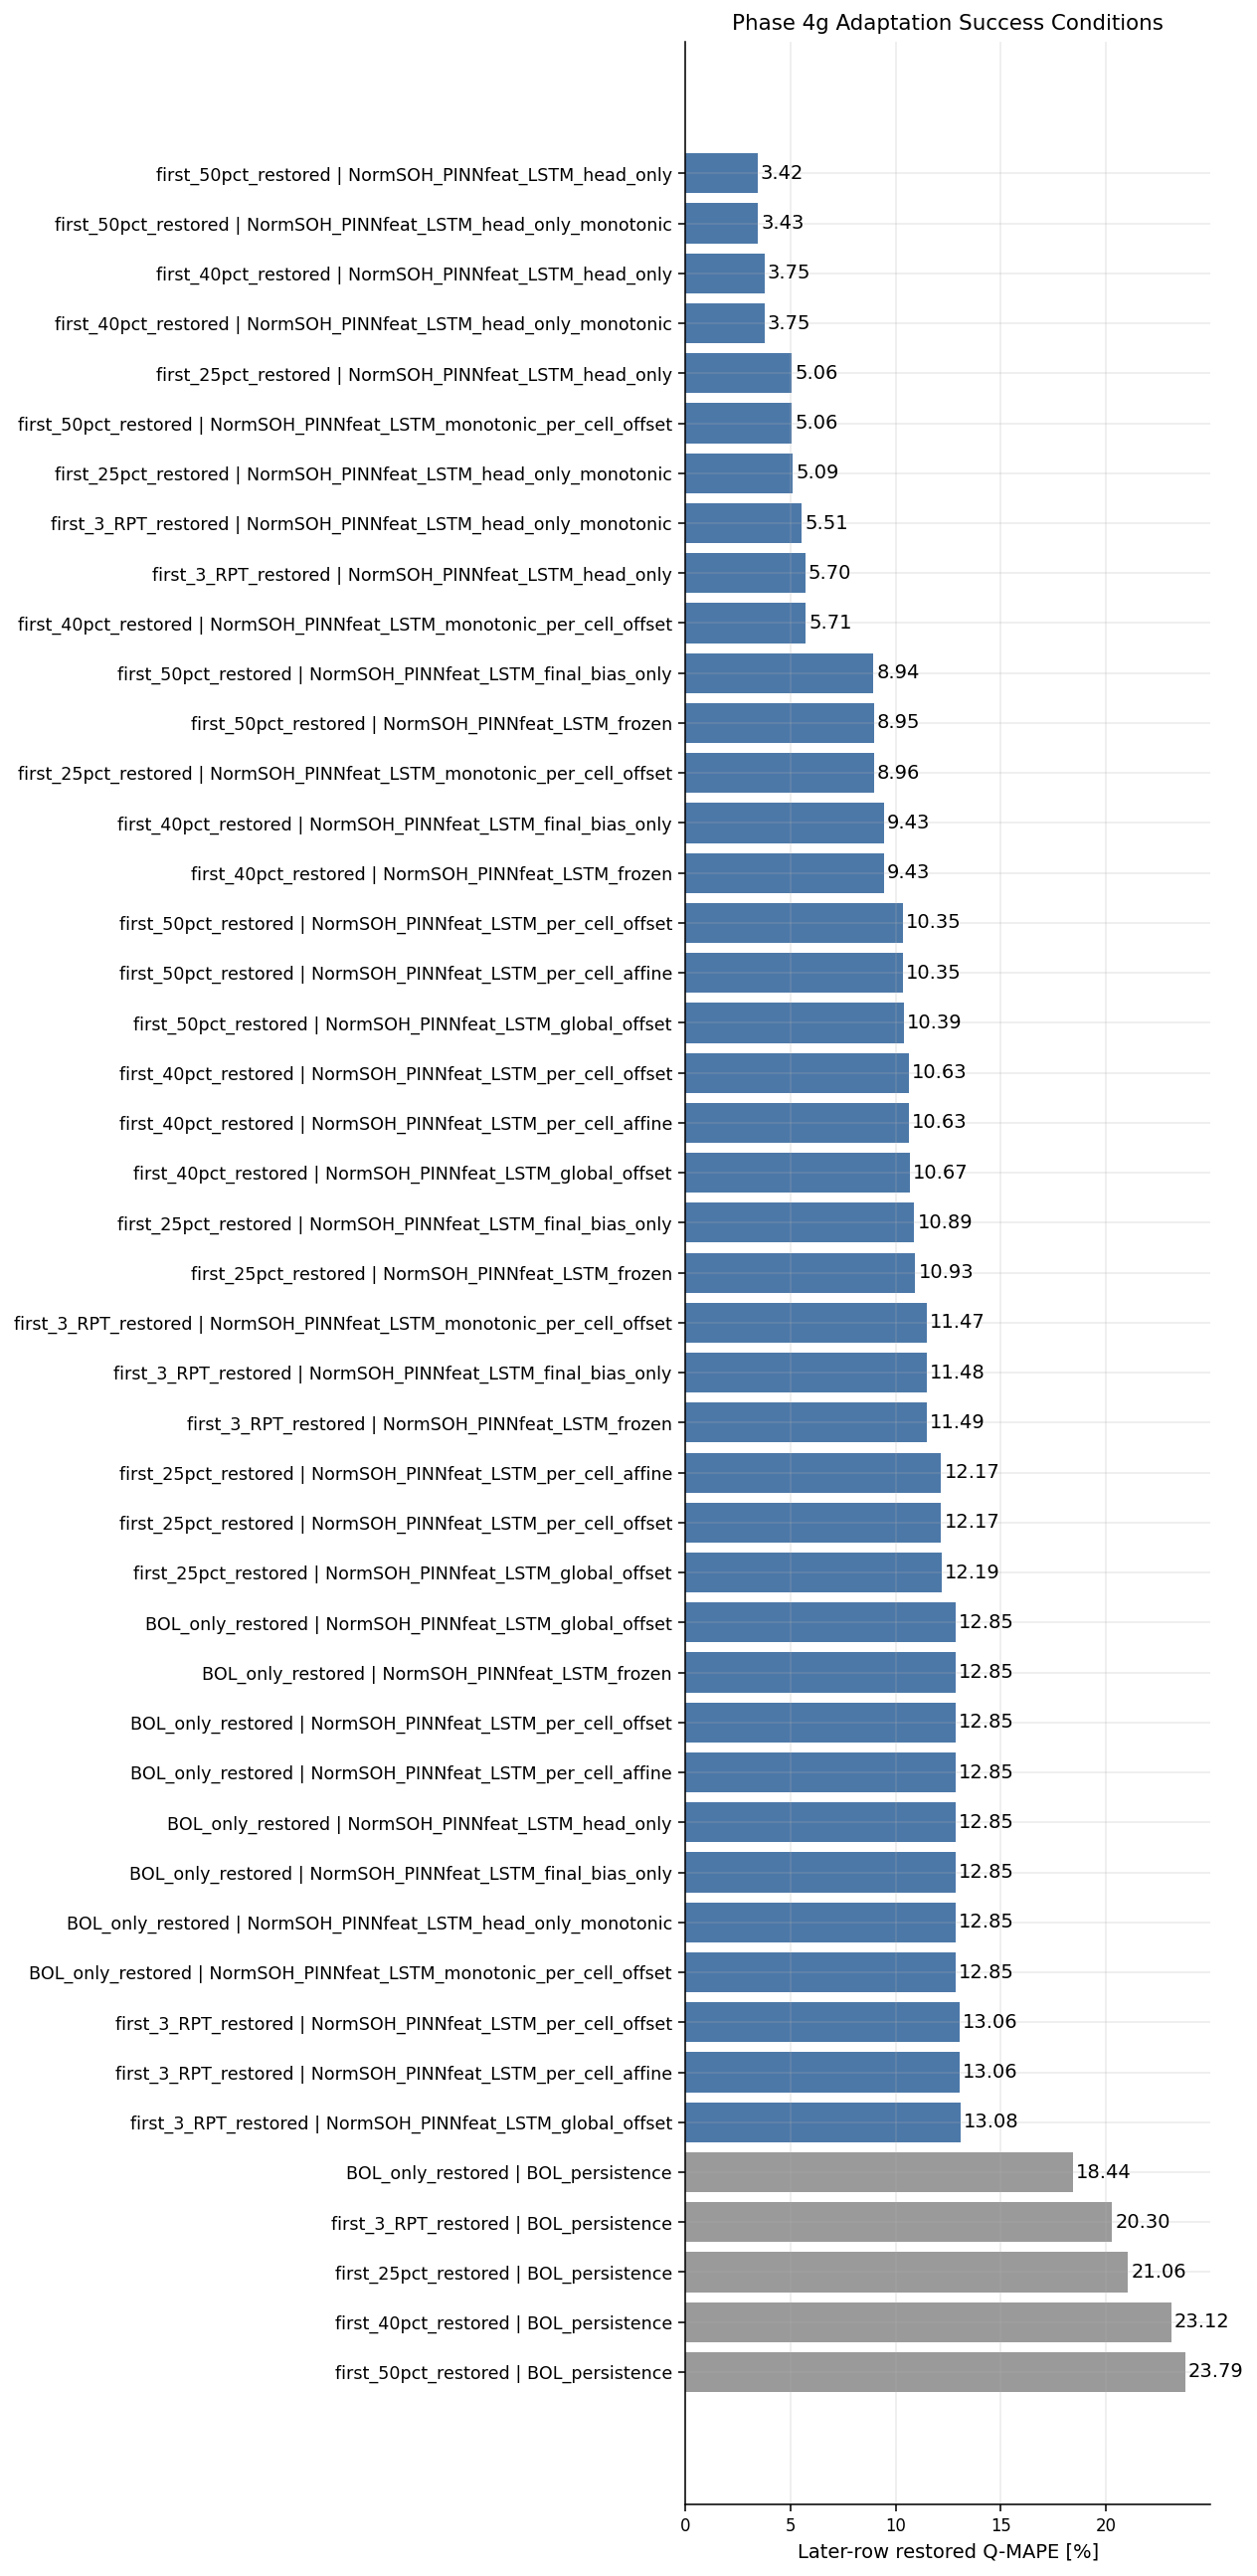

Saved: /kaggle/working/phase4g_adaptation_success_conditions_20260625_102203/figure_phase4g_best_adaptation_soh_trajectories.png


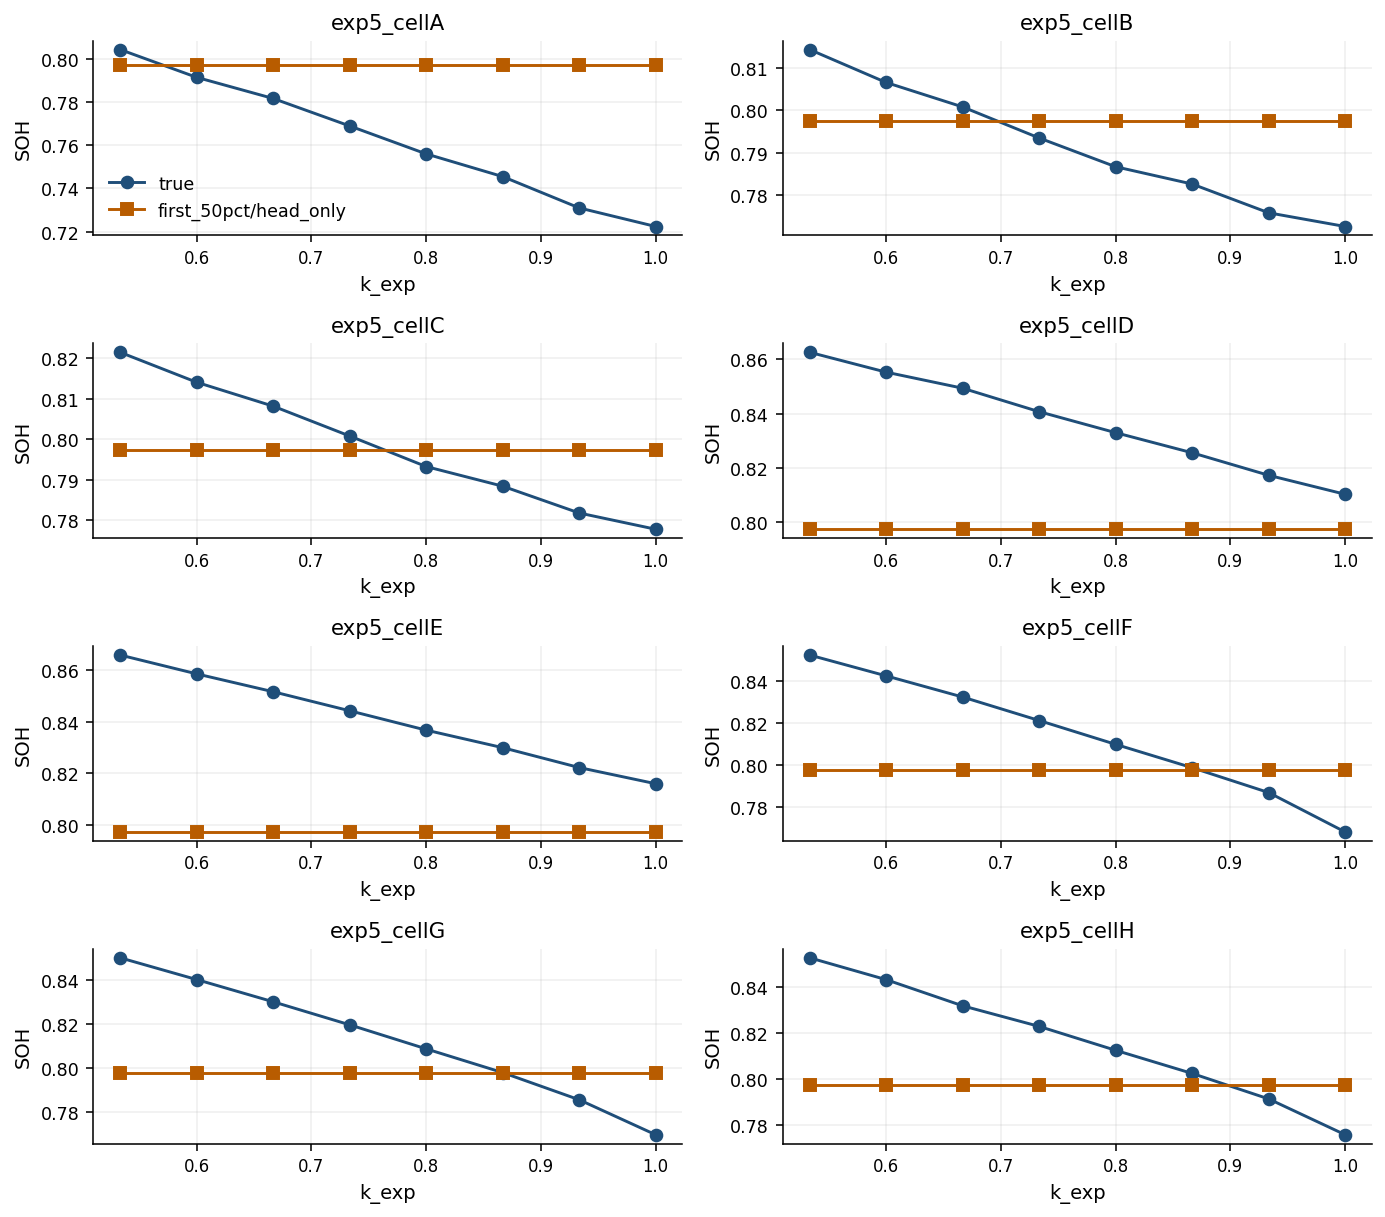

In [88]:
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 240,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def savefig(name):
    path = OUT_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    print("Saved:", path)


q_plot = paper[paper["Target"].eq("Q")].copy()
q_plot["Label"] = q_plot["Protocol"] + " | " + q_plot["Model"]
q_plot = q_plot.sort_values("MAPE")
fig, ax = plt.subplots(figsize=(9.0, max(4.2, 0.38 * len(q_plot) + 1.5)))
colors = np.where(q_plot["Model"].str.contains("persistence"), "#9A9A9A", "#4C78A8")
ax.barh(q_plot["Label"], q_plot["MAPE"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Later-row restored Q-MAPE [%]")
ax.set_title("Phase 4g Adaptation Success Conditions")
for i, v in enumerate(q_plot["MAPE"]):
    ax.text(v + 0.15, i, f"{v:.2f}", va="center")
ax.grid(axis="x", alpha=0.25)
savefig("figure_phase4g_adaptation_q_mape.png")
plt.show()

best_model_rows = best_q[best_q["Model"].astype(str).str.startswith("NormSOH_PINNfeat_LSTM_")].copy()
best_for_plot = best_model_rows.iloc[0] if len(best_model_rows) else best_q.iloc[0]
best_protocol = best_for_plot["Protocol"].replace("_restored", "")
best_model = best_for_plot["Model"]
best_adapter = best_model.replace("NormSOH_PINNfeat_LSTM_", "")
best_preds = preds_df[preds_df["Protocol"].eq(best_protocol) & preds_df["Adapter"].eq(best_adapter)].copy()
cells = list(best_preds["cell_key"].drop_duplicates())[:8]
fig, axes = plt.subplots(math.ceil(len(cells) / 2), 2, figsize=(10, max(4, 2.2 * math.ceil(len(cells) / 2))), squeeze=False)
for ax, cell in zip(axes.ravel(), cells):
    g = best_preds[best_preds["cell_key"].eq(cell)].sort_values("k_exp")
    ax.plot(g["k_exp"], g["SOH_true"], marker="o", color="#1F4E79", label="true")
    ax.plot(g["k_exp"], g["SOH_pred"], marker="s", color="#B85C00", label=f"{best_protocol}/{best_adapter}")
    ax.set_title(cell)
    ax.set_xlabel("k_exp")
    ax.set_ylabel("SOH")
    ax.grid(alpha=0.2)
for ax in axes.ravel()[len(cells):]:
    ax.axis("off")
axes.ravel()[0].legend(frameon=False)
savefig("figure_phase4g_best_adaptation_soh_trajectories.png")
plt.show()


## 9. Export


In [89]:
manifest = {
    "run_tag": RUN_TAG,
    "pack_dir": str(PACK_DIR),
    "kirk_root": str(KIRK_ROOT),
    "seq_len": SEQ_LEN,
    "features": PINN_FEATS,
    "targets": TARGETS,
    "protocols": PROTOCOLS,
    "source_epochs_requested": SOURCE_EPOCHS,
    "adapters": ADAPTERS,
    "run_fast": RUN_FAST,
    "outputs": sorted([p.name for p in OUT_DIR.iterdir()]),
}
(OUT_DIR / "phase4g_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")

zip_path = WORKING / f"{RUN_TAG}.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in sorted(OUT_DIR.rglob("*")):
        if p.is_file():
            z.write(p, arcname=p.relative_to(OUT_DIR))

print_section("Done")
print("Output directory:", OUT_DIR)
print("Zip:", zip_path)
print("Files:")
for p in sorted(OUT_DIR.iterdir()):
    print(" -", p.name)



Done
Output directory: /kaggle/working/phase4g_adaptation_success_conditions_20260625_102203
Zip: /kaggle/working/phase4g_adaptation_success_conditions_20260625_102203.zip
Files:
 - figure_phase4g_adaptation_q_mape.png
 - figure_phase4g_best_adaptation_soh_trajectories.png
 - phase4g_BOL_only_calibration_predictions.csv
 - phase4g_adaptation_claims.csv
 - phase4g_adaptation_metrics_summary.csv
 - phase4g_adaptation_predictions.csv
 - phase4g_adapter_manifest.csv
 - phase4g_calibration_manifest.csv
 - phase4g_first_25pct_calibration_predictions.csv
 - phase4g_first_25pct_final_bias_only_adaptation_history.csv
 - phase4g_first_25pct_head_only_adaptation_history.csv
 - phase4g_first_25pct_head_only_monotonic_adaptation_history.csv
 - phase4g_first_3_RPT_calibration_predictions.csv
 - phase4g_first_3_RPT_final_bias_only_adaptation_history.csv
 - phase4g_first_3_RPT_head_only_adaptation_history.csv
 - phase4g_first_3_RPT_head_only_monotonic_adaptation_history.csv
 - phase4g_first_40pct_cal